# Where are the ML Jobs, Really? A Data-Driven Look at US Postings

Exploring 1000 ML job postings from Kaggle. The project started as a search for the "best hiring season" for US ML roles, but early analysis revealed a scraping bias in the date data (most postings cluster around March-April 2025, reflecting when the data was collected, not real seasonal hiring patterns, see Step 2). From there, the focus shifted to questions the data could actually answer with confidence: where US ML jobs are concentrated, when during the week they're posted, what industries are hiring, and what natural groupings exist in job titles and company descriptions.

See the README for full findings. This notebook covers the step by step cleaning and analysis process.

## Step 1: Load the data and take a first look

In [91]:
import pandas as pd

df = pd.read_csv("1000_ml_jobs_us.csv")

print(df.shape)
print(df.columns.tolist())

(997, 10)
['Unnamed: 0', 'job_posted_date', 'company_address_locality', 'company_address_region', 'company_name', 'company_website', 'company_description', 'job_description_text', 'seniority_level', 'job_title']


In [92]:
df.head(5)

,Unnamed: 0,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title
0,0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...
1,1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer
2,2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer
3,3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training"
4,4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer


## Step 2: Convert dates and check data coverage

The `job_posted_date` column loads as plain text by default, so we convert it to a proper datetime type, then extract year and month to check how evenly the data is spread across time.

In [93]:
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

print(df["job_posted_date"].dtype)
print(df["job_posted_date"].min(), df["job_posted_date"].max())

datetime64[us]
2022-12-20 00:00:00 2025-04-09 00:00:00


In [94]:
df["year"] = df["job_posted_date"].dt.year
df["month"] = df["job_posted_date"].dt.month

print(df["year"].value_counts().sort_index())

year
2022      1
2023      2
2024     74
2025    920
Name: count, dtype: int64


In [95]:
print(df["month"].value_counts().sort_index())
print(df[df["year"] == 2025]["month"].value_counts().sort_index())

month
1      28
2      34
3     426
4     433
5       1
6       7
7       3
8       6
9       4
10      8
11     15
12     32
Name: count, dtype: int64
month
1     28
2     34
3    425
4    433
Name: count, dtype: int64


## Step 3: Clean and standardize location data

The `company_address_region` column contains inconsistent formatting (e.g. "CA" vs "California" vs "CALIFORNIA") and includes non-US locations (UK, India, Canada, etc.). This section standardizes formatting first, then filters the dataset down to recognized US states only.

In [96]:
print(df["company_address_region"].unique())

<StringArray>
[             'Indiana',           'California',                   'CA',
        'Massachusetts',                   'IL',          'Maharashtra',
       'United Kingdom',                   'MD',                    nan,
             'New York',                  'NSW',                   'TX',
                   'NY',                   'DC',                   'FL',
             'Arkansas',             'Delaware',                   'GA',
                   'ON',                   'NJ',                   'WA',
                   'NC',            'Karnataka',              'Ontario',
              'Florida',            'Guangdong',           'Washington',
                   '北京',           'CALIFORNIA',                   'MA',
              'England',                   'CO',                   'PA',
              'Bavaria',            'Minnesota',              'Georgia',
               'Nevada',             'Illinois',                   'AR',
              'Alabama',             

In [97]:
df["region_clean"] = df["company_address_region"].str.strip().str.upper()

print(df["region_clean"].unique())

<StringArray>
[             'INDIANA',           'CALIFORNIA',                   'CA',
        'MASSACHUSETTS',                   'IL',          'MAHARASHTRA',
       'UNITED KINGDOM',                   'MD',                    nan,
             'NEW YORK',                  'NSW',                   'TX',
                   'NY',                   'DC',                   'FL',
             'ARKANSAS',             'DELAWARE',                   'GA',
                   'ON',                   'NJ',                   'WA',
                   'NC',            'KARNATAKA',              'ONTARIO',
              'FLORIDA',            'GUANGDONG',           'WASHINGTON',
                   '北京',                   'MA',              'ENGLAND',
                   'CO',                   'PA',              'BAVARIA',
            'MINNESOTA',              'GEORGIA',               'NEVADA',
             'ILLINOIS',                   'AR',              'ALABAMA',
              'ARIZONA', 'DISTRICT OF

### Mapping abbreviations to full state names, and filtering to US-only rows

A manually built dictionary maps two-letter abbreviations to full state names, so entries like "CA" and "California" are treated as identical. Rows that don't match any recognized US state (non-US countries, or invalid values like stray zip codes) are excluded, with one exception: a known zip code (94086, Sunnyvale) was manually corrected to California rather than dropped, since it was a clearly identifiable, recoverable value.

In [98]:
zip_fixes = {
    "94086": "CALIFORNIA"
}

df["region_clean"] = df["region_clean"].replace(zip_fixes)

In [99]:
us_states = {
    "AL": "ALABAMA", "AK": "ALASKA", "AZ": "ARIZONA", "AR": "ARKANSAS",
    "CA": "CALIFORNIA", "CO": "COLORADO", "CT": "CONNECTICUT", "DE": "DELAWARE",
    "FL": "FLORIDA", "GA": "GEORGIA", "HI": "HAWAII", "ID": "IDAHO",
    "IL": "ILLINOIS", "IN": "INDIANA", "IA": "IOWA", "KS": "KANSAS",
    "KY": "KENTUCKY", "LA": "LOUISIANA", "ME": "MAINE", "MD": "MARYLAND",
    "MA": "MASSACHUSETTS", "MI": "MICHIGAN", "MN": "MINNESOTA", "MS": "MISSISSIPPI",
    "MO": "MISSOURI", "MT": "MONTANA", "NE": "NEBRASKA", "NV": "NEVADA",
    "NH": "NEW HAMPSHIRE", "NJ": "NEW JERSEY", "NM": "NEW MEXICO", "NY": "NEW YORK",
    "NC": "NORTH CAROLINA", "ND": "NORTH DAKOTA", "OH": "OHIO", "OK": "OKLAHOMA",
    "OR": "OREGON", "PA": "PENNSYLVANIA", "RI": "RHODE ISLAND", "SC": "SOUTH CAROLINA",
    "SD": "SOUTH DAKOTA", "TN": "TENNESSEE", "TX": "TEXAS", "UT": "UTAH",
    "VT": "VERMONT", "VA": "VIRGINIA", "WA": "WASHINGTON", "WV": "WEST VIRGINIA",
    "WI": "WISCONSIN", "WY": "WYOMING", "DC": "DISTRICT OF COLUMBIA"
}

valid_regions = set(us_states.keys()) | set(us_states.values())

df["region_std"] = df["region_clean"].replace(us_states)

is_valid_us = df["region_std"].isin(valid_regions)
print(df.loc[~is_valid_us, "region_clean"].value_counts())

region_clean
ENGLAND           14
LONDON            10
MAHARASHTRA        4
ONTARIO            4
BAVARIA            4
CHINA              4
UNITED KINGDOM     3
GUANGDONG          3
.                  3
MH                 3
NSW                2
ON                 1
KARNATAKA          1
北京                 1
GYEONGGI-DO        1
ESSEX              1
ÎLE-DE-FRANCE      1
CHILE              1
GREATER LONDON     1
COUNTY DUBLIN      1
TOKYO              1
BC                 1
Name: count, dtype: int64


In [100]:
df_us = df[is_valid_us].copy()

print(df.shape)
print(df_us.shape)

(997, 14)
(819, 14)


## Step 4: Geographic concentration of ML job postings

California dominates the dataset overwhelmingly, and within California, postings cluster heavily around the San Francisco Bay Area specifically (San Francisco, Menlo Park, San Jose, Mountain View, and Los Gatos all appear in the top 10 cities).

In [101]:
import matplotlib.pyplot as plt

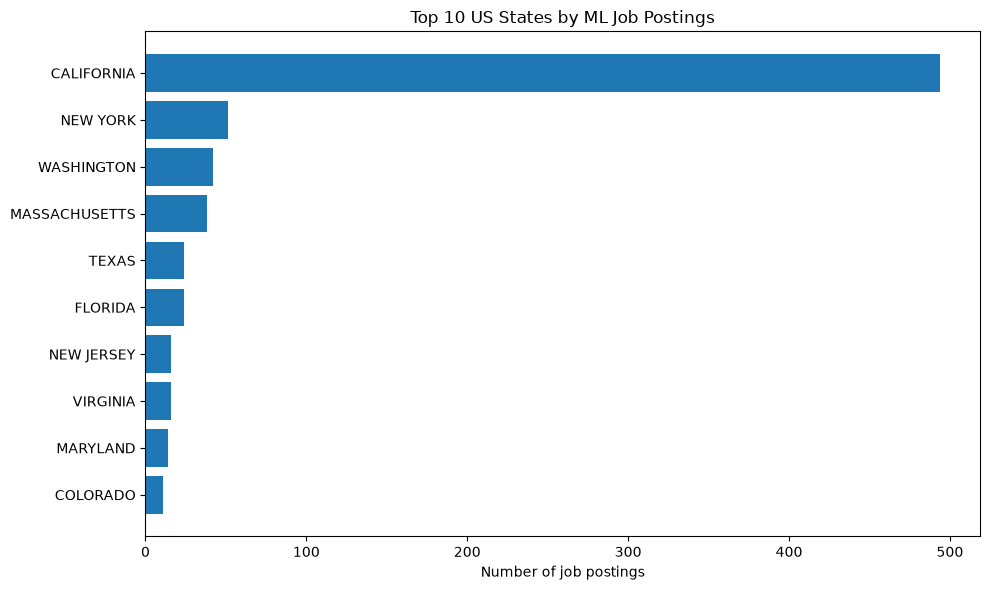

In [102]:
top_states = df_us["region_std"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_states.index[::-1], top_states.values[::-1])
plt.xlabel("Number of job postings")
plt.title("Top 10 US States by ML Job Postings")
plt.tight_layout()
plt.show()

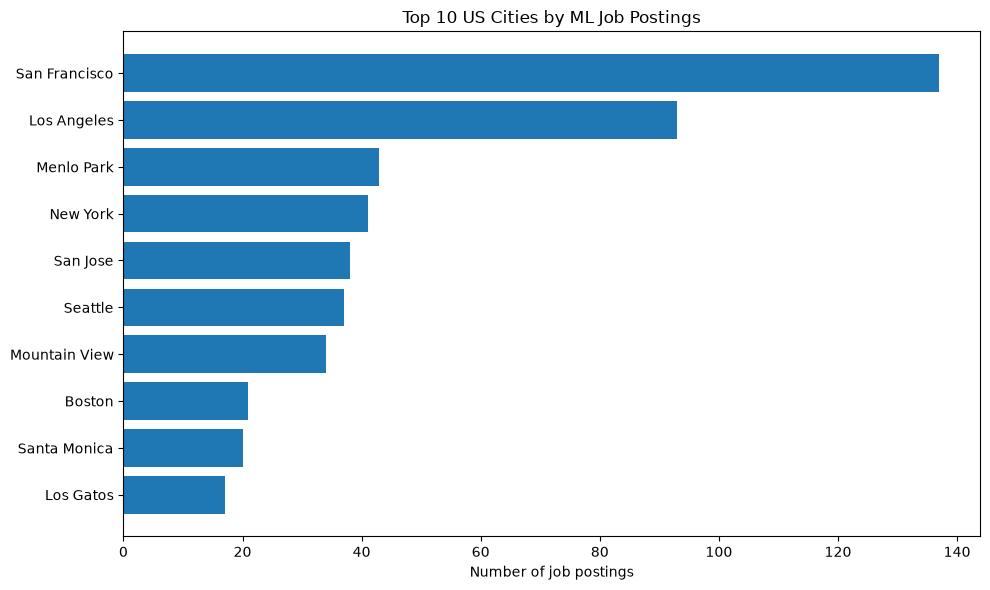

In [103]:
top_cities = df_us["company_address_locality"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cities.index[::-1], top_cities.values[::-1])
plt.xlabel("Number of job postings")
plt.title("Top 10 US Cities by ML Job Postings")
plt.tight_layout()
plt.show()

## Step 5: Day-of-week posting patterns

Since the monthly "season" signal is compromised by the data scraping bias noted above, day-of-week is a more reliable timing angle within the March-April 2025 window. Wednesday shows a notable spike in postings, worth further investigation into whether this reflects real hiring behavior or scraping timing, it cannot be confirmed with certainty from this data alone.

In [104]:
df_us["day_of_week"] = df_us["job_posted_date"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df_us["day_of_week"].value_counts().reindex(day_order)

print(day_counts)

day_of_week
Monday       107
Tuesday      139
Wednesday    222
Thursday     116
Friday       124
Saturday      60
Sunday        51
Name: count, dtype: int64


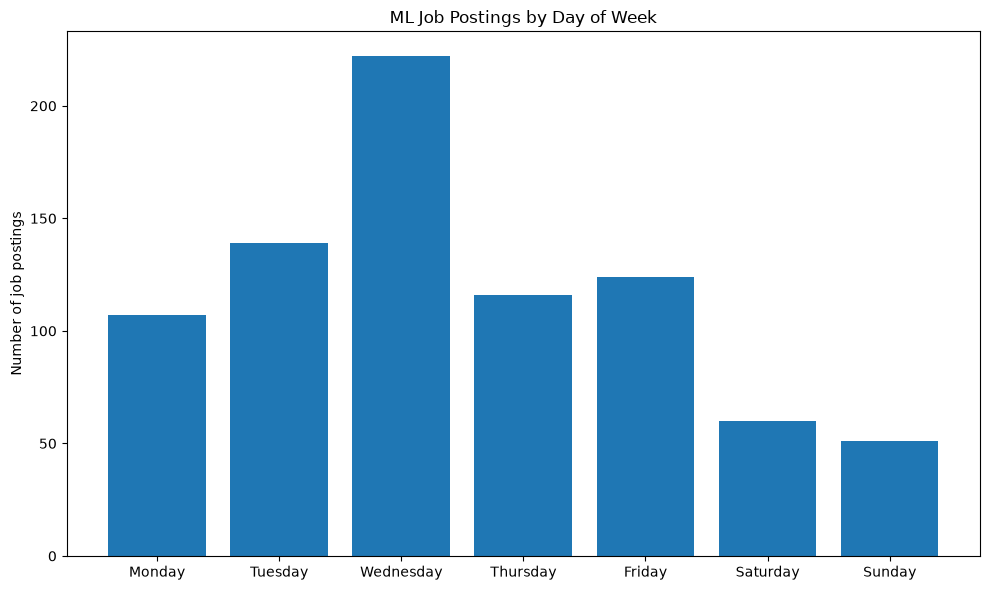

In [105]:
plt.figure(figsize=(10, 6))
plt.bar(day_counts.index, day_counts.values)
plt.ylabel("Number of job postings")
plt.title("ML Job Postings by Day of Week")
plt.tight_layout()
plt.show()

## Step 6: Inferring the industry from company descriptions

There's no industry column in the raw data, so industry is inferred using two combined methods: 
(1) a manual lookup for well known, high-volume companies (e.g. TikTok, Meta, Amazon) where the industry is common knowledge, and 
(2) keyword matching against company description text for everything else. 
This approach still leaves roughly 16% of postings unclassified ("Other/Unmatched"), mostly companies with vague or brand-driven marketing copy rather than descriptive text. A more advanced NLP technique (topic modeling) could reduce this further, but was judged out of scope for this method.


In [106]:
print(df_us["company_name"].nunique())
print(df_us.shape[0])

top_companies = df_us["company_name"].value_counts().head(10)
print(top_companies)

373
819
company_name
TikTok                       88
Meta                         39
Adobe                        18
Splunk                       18
Snap Inc.                    18
Netflix                      17
DoorDash                     17
Amazon                       15
Amazon Web Services (AWS)    13
Waymo                        11
Name: count, dtype: int64


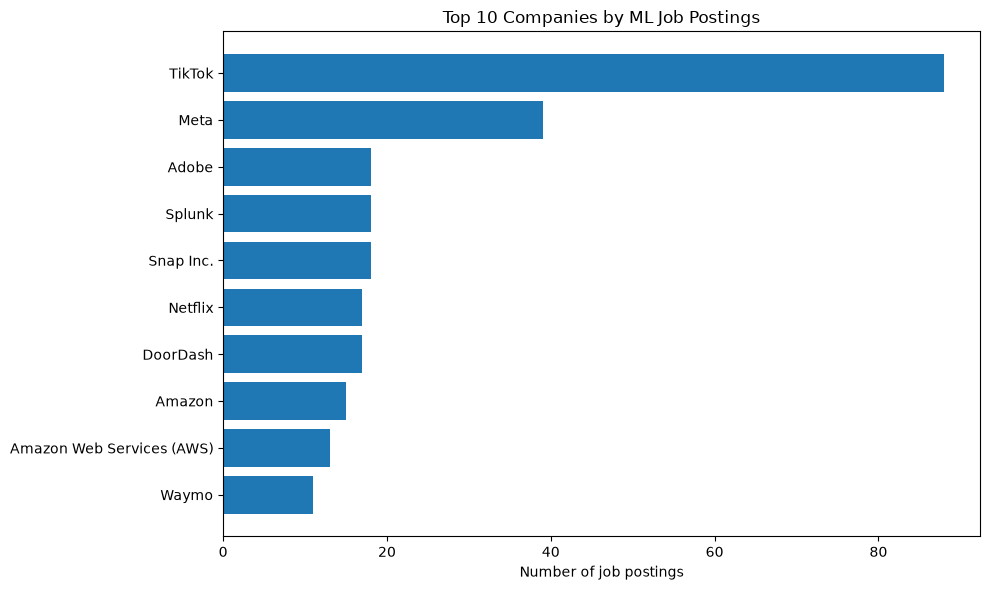

In [107]:
plt.figure(figsize=(10, 6))
plt.barh(top_companies.index[::-1], top_companies.values[::-1])
plt.xlabel("Number of job postings")
plt.title("Top 10 Companies by ML Job Postings")
plt.tight_layout()
plt.show()

In [108]:
sample_df = df_us[["company_name", "company_description"]].dropna().sample(10, random_state=42)

for _, row in sample_df.iterrows():
    print(row["company_name"])
    print(row["company_description"][:300])
    print("-" * 40)

FERMÀT
Tailor Every Touchpoint. Convert more paid traffic by experimenting & owning your post-click experience.

GET STARTED:
Book a call with our team here: https://fermatcommerce.co/3VYWycn

HAVE QUESTIONS?
Drop us a message here: hello@fermatcommerce.com
----------------------------------------
First Soft Solutions LLC
When you hire First Soft Solutions, you're hiring a strategic technology consulting partner committed to helping you meet your unique business and technology objectives on time, on budget and with an optimal experience. We apply the expertise of our global community of technology experts, an unmatch
----------------------------------------
Voxel51
Build better visual AI faster with FiftyOne by Voxel51. We empower AI builders to understand and improve visual datasets and evaluate their models, leading to more accurate results and streamlined workflows. Unlock the power of your visual data.
----------------------------------------
First Soft Solutions LLC
When you hire 

In [109]:
industry_keywords = {
    "AI/ML Product & Research": ["artificial intelligence", "machine learning", "computer vision", "deep learning", "autonomous"],
    "IT Consulting & Staffing": ["consulting", "staffing", "recruit", "talent solutions", "IT services", "digital transformation"],
    "Social Media & Entertainment": ["social media", "streaming", "entertainment", "short-form video", "content creators"],
    "E-commerce & Retail": ["e-commerce", "ecommerce", "retail", "marketplace", "delivery"],
    "Enterprise Software & Cloud": ["cloud", "enterprise software", "saas", "platform"],
    "Financial Services": ["bank", "financial services", "fintech", "payments"],
    "Healthcare": ["healthcare", "medtech", "patient", "medicine", "hospital"],
    "Automotive & Transportation": ["vehicle", "automotive", "driverless", "autonomous vehicles"],
    "Energy": ["energy", "utilities", "power grid", "sustainability"],
    "Marketing & Sales": ["sales intelligence", "b2b", "marketing data", "pipeline"],
    "Real Estate & PropTech": ["real estate", "mortgage", "proptech", "housing market"],
    "Aerospace & Defense": ["aerospace", "defense", "satellite", "space exploration", "military"],
    "Legal Services": ["legal", "law firm", "litigation", "attorney"],
    "Creative & Design Software": ["digital media", "digital marketing", "creative software", "design tools"]
}

known_company_industries = {
    "TikTok": "Social Media & Entertainment",
    "Meta": "Social Media & Entertainment",
    "Snap Inc.": "Social Media & Entertainment",
    "Twitch": "Social Media & Entertainment",
    "Netflix": "Social Media & Entertainment",
    "Adobe": "Creative & Design Software",
    "Splunk": "Enterprise Software & Cloud",
    "Microsoft": "Enterprise Software & Cloud",
    "Salesforce": "Enterprise Software & Cloud",
    "DoorDash": "E-commerce & Retail",
    "Amazon": "E-commerce & Retail",
    "Amazon Web Services (AWS)": "Enterprise Software & Cloud",
    "Airbnb": "E-commerce & Retail",
    "PayPal": "Financial Services",
    "Robinhood": "Financial Services",
    "Waymo": "Automotive & Transportation",
    "Rivian": "Automotive & Transportation",
    "Lockheed Martin": "Aerospace & Defense",
    "Nextdoor": "Social Media & Entertainment",
    "Notion": "Enterprise Software & Cloud",
    "Cisco": "Enterprise Software & Cloud",
    }

def classify_industry(description, company_name):
    if company_name in known_company_industries:
        return known_company_industries[company_name]
    if pd.isna(description):
        return "Unknown"
    text = description.lower()
    for industry, keywords in industry_keywords.items():
        for keyword in keywords:
            if keyword in text:
                return industry
    return "Other/Unmatched"

df_us["industry_guess"] = df_us.apply(lambda row: classify_industry(row["company_description"], row["company_name"]), axis=1)

print(df_us["industry_guess"].value_counts())

industry_guess
Social Media & Entertainment    186
Enterprise Software & Cloud     176
Other/Unmatched                 117
E-commerce & Retail              88
IT Consulting & Staffing         80
AI/ML Product & Research         68
Automotive & Transportation      30
Creative & Design Software       19
Financial Services               16
Healthcare                       16
Aerospace & Defense               8
Energy                            5
Marketing & Sales                 4
Real Estate & PropTech            2
Legal Services                    2
Unknown                           2
Name: count, dtype: int64


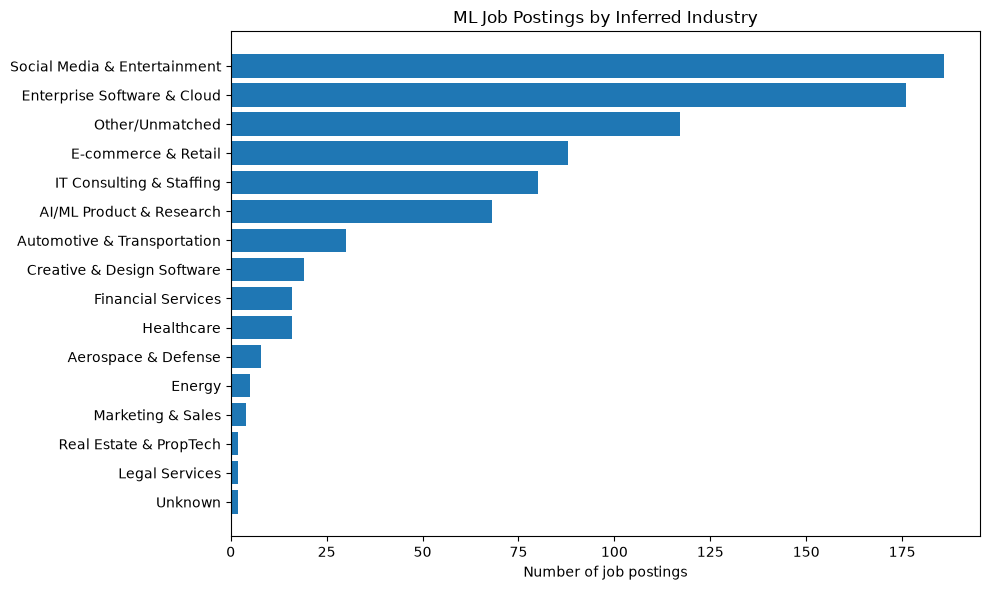

In [110]:
industry_counts = df_us["industry_guess"].value_counts()

plt.figure(figsize=(10, 6))
plt.barh(industry_counts.index[::-1], industry_counts.values[::-1])
plt.xlabel("Number of job postings")
plt.title("ML Job Postings by Inferred Industry")
plt.tight_layout()
plt.show()

### Comparison against unsupervised machine learning

Having manually classified industries using domain knowledge and keyword rules (Step 6), this section takes a different approach: clustering company descriptions purely on textual similarity, with no predefined categories or company knowledge involved. This allows a comparison between a domain-informed method and a purely data-driven one, revealing whether the same real world groupings emerge independently, or whether the text reveals a different underlying structure entirely.

In [128]:
desc_vectorizer = TfidfVectorizer(stop_words="english", max_features=300)
desc_vectors = desc_vectorizer.fit_transform(df_us["company_description"].fillna(""))

print(desc_vectors.shape)

(819, 300)


In [129]:
num_desc_clusters = 8
desc_kmeans = KMeans(n_clusters=num_desc_clusters, random_state=42, n_init=10)
df_us["desc_cluster"] = desc_kmeans.fit_predict(desc_vectors)

print(df_us["desc_cluster"].value_counts().sort_index())

desc_cluster
0    127
1     39
2     54
3     88
4     45
5     87
6     33
7    346
Name: count, dtype: int64


In [130]:
for cluster_num in range(num_desc_clusters):
    print(f"--- Cluster {cluster_num} ({(df_us['desc_cluster'] == cluster_num).sum()} companies) ---")
    sample = df_us.loc[df_us["desc_cluster"] == cluster_num, ["company_name", "company_description"]].dropna().head(6)
    for _, row in sample.iterrows():
        print(row["company_name"], "-", row["company_description"][:150])
    print()

--- Cluster 0 (127 companies) ---
Interclypse - Interclypse is a small business headquartered in Annapolis Junction, Maryland, focused on solving complex problems for customers across the US Intelli
Russell Tobin - Bring Top Talent With Your Company With Russell Tobin
Headquartered in New York City with offices throughout the United States, United Kingdom, Irelan
Lockheed Martin - The world relies on what we do. 

Headquartered in Bethesda, Maryland, with offices across the U.S. and around the globe, our team delivers solutions 
INSPYR Solutions - Technology is our focus and quality is our commitment. As a national expert in delivering flexible technology and talent solutions, we strategically a
Accroid Inc - Accroid Inc is a nationwide employment and service provider committed to enabling individuals. We firmly believe that everything is possible when we w
Interclypse - Interclypse is a small business headquartered in Annapolis Junction, Maryland, focused on solving complex problems f

### Refining the approach: deduplicating before clustering

The initial clustering on company descriptions (one row per job posting)
mostly rediscovered exact-duplicate postings from high-volume employers
(e.g. Meta, TikTok, Netflix each formed their own cluster simply because
their description text repeats identically across many postings), rather
than genuine industry or topical structure. One cluster did show real
promise: a group of AI/enterprise tech product companies (Ikigai, Arthur,
Glean, Articul8 AI, and others) with no duplicate text between them,
grouped purely on shared vocabulary.

To test whether removing this duplicate-posting bias reveals clearer
structure, the dataset is deduplicated to one row per unique company
before re-running TF-IDF and K-Means.

### Verifying the deduplication assumption

Checked across all 373 companies: none have more than one distinct
description. Deduplicating to one row per company loses no information,
it only removes exact duplicate text.

In [131]:
desc_variation = df_us.groupby("company_name")["company_description"].nunique()
print(desc_variation[desc_variation > 1])

Series([], Name: company_description, dtype: int64)


In [132]:
company_desc_unique = df_us.drop_duplicates(subset="company_name")[["company_name", "company_description"]].dropna()

print(company_desc_unique.shape)

(372, 2)


In [133]:
company_vectorizer = TfidfVectorizer(stop_words="english", max_features=300)
company_vectors = company_vectorizer.fit_transform(company_desc_unique["company_description"])

company_kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
company_desc_unique["cluster"] = company_kmeans.fit_predict(company_vectors)

print(company_desc_unique["cluster"].value_counts().sort_index())

cluster
0    31
1    52
2    32
3    21
4    80
5    36
6    65
7    55
Name: count, dtype: int64


In [134]:
for cluster_num in range(8):
    print(f"--- Cluster {cluster_num} ({(company_desc_unique['cluster'] == cluster_num).sum()} companies) ---")
    sample = company_desc_unique[company_desc_unique["cluster"] == cluster_num].head(6)
    for _, row in sample.iterrows():
        print(row["company_name"], "-", row["company_description"][:150])
    print()

--- Cluster 0 (31 companies) ---
Upper Hand - Upper Hand is the leading provider of full-suite sports management software that enable businesses to achieve more while doing less.

Sports facilitie
HMH - We are an adaptive learning company that empowers educators. With a focus on what moves each learner, HMH delivers what teachers need to foster growth
Netflix - Netflix is one of the world's leading entertainment services, with over 300 million paid memberships in over 190 countries enjoying TV series, films a
Splunk - Splunk is helping to build a safer and more resilient digital world by equipping customers with the unified security and observability platform they n
Escalon Services - If you’re like us, you’re in business to do what you love—build great products, teams, and customer relationships. Paying bills, generating financial 
Amazon - Amazon is guided by four principles: customer obsession rather than competitor focus, passion for invention, commitment to operational excellence,

### Results: deduplicated clustering

Deduplication revealed clearer structure than the posting-level clustering.
Several clusters are genuinely coherent: IT staffing/recruiting, healthcare/
medtech, and AI/ML product companies each formed distinct groups, matching
categories from the manual approach (Step 6), independently and without
manual rules. Other clusters remained mixed, likely reflecting companies
whose descriptions lack distinctive industry language. Full comparison and
discussion in the README.

### Comparing manual vs. clustered industry labels

In [135]:
manual_labels = df_us.drop_duplicates(subset="company_name")[["company_name", "industry_guess"]]

comparison = company_desc_unique.merge(manual_labels, on="company_name")

crosstab = pd.crosstab(comparison["cluster"], comparison["industry_guess"])
print(crosstab)

industry_guess  AI/ML Product & Research  Aerospace & Defense  \
cluster                                                         
0                                      0                    0   
1                                      8                    2   
2                                      2                    0   
3                                      1                    0   
4                                      5                    2   
5                                      9                    1   
6                                      9                    0   
7                                     13                    0   

industry_guess  Automotive & Transportation  Creative & Design Software  \
cluster                                                                   
0                                         0                           0   
1                                         1                           0   
2                                         0      

## Step 7: Job title clustering using clustering

Job titles were converted into numeric vectors using TF-IDF, then grouped into 8 clusters using K-Means, with no predefined categories. The algorithm separated titles by seniority, career stage, specialization, and role type on its own. PCA was used to compress the vectors down to 3D for visualization. 
See README for full findings and limitations.

In [119]:
print(df_us["job_title"].nunique())
print(df_us["job_title"].value_counts().head(20))

390
job_title
Machine Learning Engineer                                          174
Data Scientist                                                      39
Software Engineer, Machine Learning                                 28
Senior Machine Learning Engineer                                    15
Machine Learning Engineer, AI (FULLY REMOTE, USA)                    9
Software Engineer, Machine Learning (Multiple Levels) - Slack        9
Machine Learning Engineer, AI Platform (FULLY REMOTE, USA ONLY)      8
Artificial Intelligence / Data Scientist Intern (HR)                 8
Machine Learning Engineer, Level 5                                   7
Software Engineer                                                    7
Machine Learning Engineer, Level 4                                   6
Machine Learning Engineer II                                         6
Machine Learning Engineer, Generative AI Innovation Center           6
Data Scientist - All Levels                                    

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=200)
title_vectors = vectorizer.fit_transform(df_us["job_title"])

print(title_vectors.shape)

(819, 200)


In [121]:
from sklearn.cluster import KMeans

num_clusters = 8
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_us["title_cluster"] = kmeans.fit_predict(title_vectors)

print(df_us["title_cluster"].value_counts().sort_index())

title_cluster
0    152
1     63
2    191
3     15
4    196
5     40
6     65
7     97
Name: count, dtype: int64


In [122]:
for cluster_num in range(num_clusters):
    print(f"--- Cluster {cluster_num} ---")
    sample_titles = df_us.loc[df_us["title_cluster"] == cluster_num, "job_title"].head(8)
    for title in sample_titles:
        print(title)
    print()

--- Cluster 0 ---
Software Engineer, Machine Learning
Software Engineer, Machine Learning
Software Engineer L4, Machine Learning Platform (Metaflow)
ML Software Engineer (L4/L5) - Media Algorithms
Machine Learning Software Engineer L4/L5
Software Engineer, Machine Learning
Software Engineer 5, Data Clean Room
Software Engineer, Machine Learning

--- Cluster 1 ---
AI / Machine Learning Engineer
Machine Learning Engineer, Generative AI
Machine Learning Engineer, Generative AI
Machine Learning Engineer, AI (FULLY REMOTE, USA)
Machine Learning Engineer, AI (FULLY REMOTE, USA)
Machine Learning Engineer - AI Agent
Machine Learning Engineer, AI (FULLY REMOTE, USA)
Machine Learning Engineer, AI (FULLY REMOTE, USA)

--- Cluster 2 ---
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer
Machine Learning Engineer

--- Cluster 3 ---
Data Engineer/ Analytics Engineer
Arti

In [123]:
cluster_labels = {
    0: "Software Engineer (ML specialization)",
    1: "AI / Generative AI Engineer",
    2: "Machine Learning Engineer (general)",
    3: "Hybrid Data Science / Analytics Roles",
    4: "ML Engineer (team/product specific)",
    5: "Senior Machine Learning Engineer",
    6: "Internship / Entry-level ML Roles",
    7: "Data Scientist",
}

df_us["title_cluster_label"] = df_us["title_cluster"].map(cluster_labels)

print(df_us["title_cluster_label"].value_counts())

title_cluster_label
ML Engineer (team/product specific)      196
Machine Learning Engineer (general)      191
Software Engineer (ML specialization)    152
Data Scientist                            97
Internship / Entry-level ML Roles         65
AI / Generative AI Engineer               63
Senior Machine Learning Engineer          40
Hybrid Data Science / Analytics Roles     15
Name: count, dtype: int64


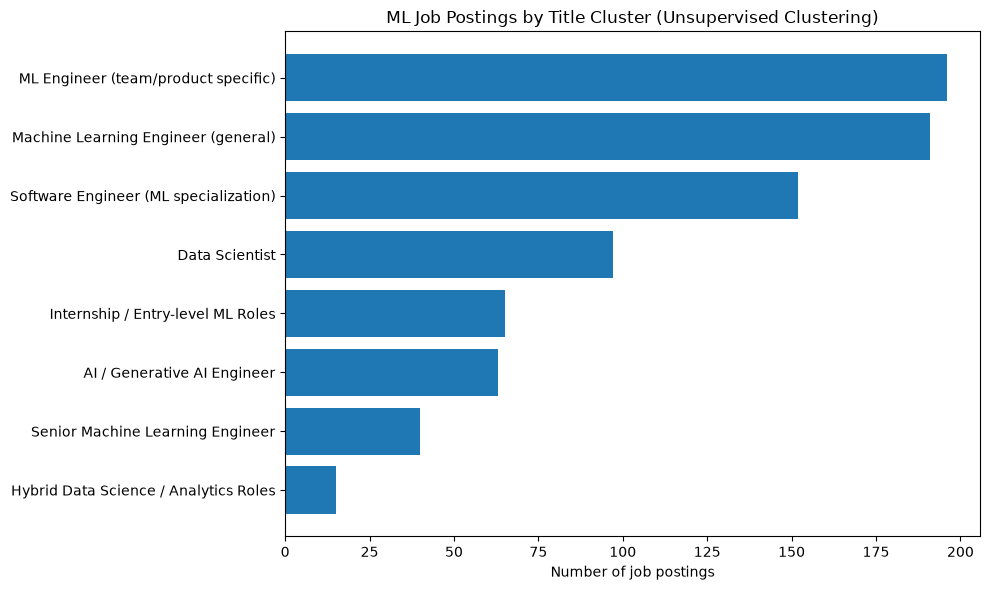

In [124]:
cluster_counts = df_us["title_cluster_label"].value_counts()

plt.figure(figsize=(10, 6))
plt.barh(cluster_counts.index[::-1], cluster_counts.values[::-1])
plt.xlabel("Number of job postings")
plt.title("ML Job Postings by Title Cluster (Unsupervised Clustering)")
plt.tight_layout()
plt.show()

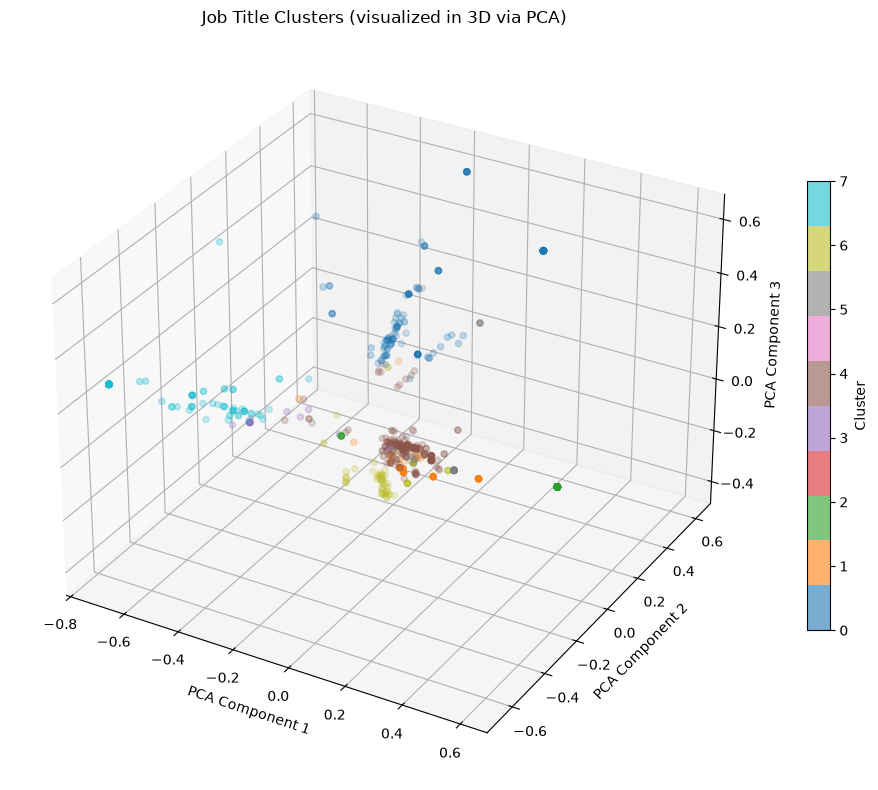

In [125]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
title_vectors_3d = pca.fit_transform(title_vectors.toarray())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    title_vectors_3d[:, 0],
    title_vectors_3d[:, 1],
    title_vectors_3d[:, 2],
    c=df_us["title_cluster"],
    cmap="tab10",
    alpha=0.6,
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("Job Title Clusters (visualized in 3D via PCA)")
plt.colorbar(scatter, label="Cluster", ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

## Exporting the cleaned dataset

Saves the cleaned, US-only dataset (with standardized regions and
extracted date parts) as a checkpoint file for reuse.

In [126]:
df_us.to_csv("cleaned_ml_jobs_us.csv", index=False)